In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime
import pickle as pkl
import zlib
import base64

In [9]:

from src.envs.trainer import Trainer
from src.envs.strategy import LazyGreedyStrategy, RandomStrategy, load_strategy

In [10]:
agents_info = [
    {
        'strategy': LazyGreedyStrategy(),
        'state_type': 'closest',
        'eps': 0.05,
        'train': True,
        'alpha': 0.3,
        'gamma': 0.5
    },
    {
        'strategy': load_strategy('../output/2025-05-01/02:19:04.597189'),
        'state_type': 'closest',
        'eps': 0.05,
    },
    {
        'strategy': load_strategy('../output/2025-05-01/03:12:02.284385'),
        'state_type': 'closest',
        'eps': 0.05,
    },
    {
        'strategy': RandomStrategy(),
        'state_type': 'closest',
    },
]

In [11]:
trainer = Trainer(num_experiments=2000, agents_info=agents_info, can_wait=True, league_level=1, reward_for_win=100)

In [12]:
reward_list = []
quality_list = []

for i in tqdm(range(trainer.num_experiments)):
    rollout_rewards = trainer.play_rollout()
    reward_list.append(rollout_rewards)
    quality_list.append(trainer.agents[0].check_policy())
    if i % 10 == 0:
        total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
        mean_rewards = np.mean(total_reward_list, axis=0)
        quality_metric = trainer.agents[0].check_policy()
        mean_reward_metric = f"[{', '.join(f'{x:.2f}' for x in mean_rewards)}]"
        print(f"i={i}\tquality={quality_metric:.2f}\tmean_reward={mean_reward_metric}")

  0%|          | 1/2000 [00:00<19:42,  1.69it/s]

i=0	quality=0.18	mean_reward=[-168.00, -154.00, 7.00, -168.00]


  1%|          | 11/2000 [00:07<23:46,  1.39it/s]

i=10	quality=0.18	mean_reward=[-166.91, -105.27, -35.36, -175.64]


  1%|          | 21/2000 [00:15<22:40,  1.45it/s]

...

i=70	quality=0.35	mean_reward=[-151.04, -99.08, -61.62, -174.30]


  4%|▍         | 81/2000 [00:59<20:13,  1.58it/s]

i=80	quality=0.29	mean_reward=[-152.54, -102.56, -60.33, -174.78]


  4%|▍         | 84/2000 [01:02<23:40,  1.35it/s]


KeyboardInterrupt: 

In [13]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [14]:
winner_list = np.argmax(total_reward_list, 1)

In [15]:
Counter(winner_list)

Counter({2: 50, 1: 28, 0: 5, 3: 1})

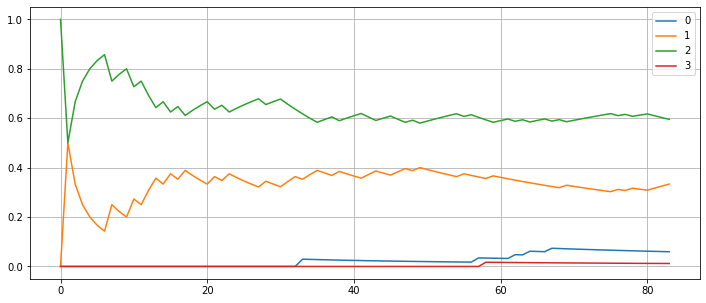

In [16]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

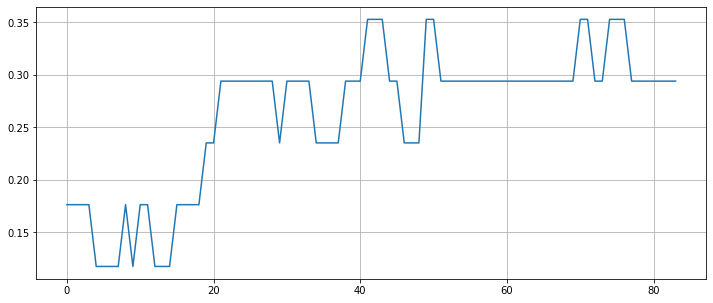

In [18]:
plt.figure(figsize=(12, 5))
sns.lineplot(quality_list)
_ = plt.grid()

In [43]:
val_agents_info = []
for x in agents_info:
    x = dict(x)
    x['train'] = False
    x['eps'] = 0
    val_agents_info.append(x)
val_agents_info[0]['strategy'] = trainer.agents[0].strategy

In [44]:
val_trainer = Trainer(num_experiments=10, agents_info=val_agents_info, can_wait=True, league_level=1, reward_for_win=100)

In [45]:
reward_list = []
quality_list = []

for i in tqdm(range(val_trainer.num_experiments)):
    rollout_rewards = val_trainer.play_rollout()
    reward_list.append(rollout_rewards)
    quality_list.append(val_trainer.agents[0].check_policy())

100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


In [46]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [47]:
winner_list = np.argmax(total_reward_list, 1)

In [48]:
Counter(winner_list)

Counter({2: 9, 1: 1})

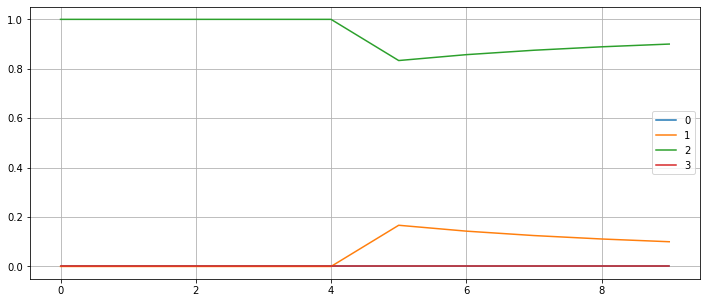

In [49]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [50]:
val_trainer.agents[0].check_policy()

0.29411764705882354

In [31]:
training_pi = trainer.agents[0].strategy

In [32]:
len([k for k in training_pi.Q.keys()])

898

In [33]:
# new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 6)]
new_keys = list(training_pi.Q.keys())

In [34]:
len(new_keys)

898

In [35]:
data1 = pkl.dumps(np.array(list(training_pi.Q[k] for k in new_keys), dtype='float16'))
data2 = pkl.dumps(list(new_keys))

In [36]:
len(base64.b64encode(zlib.compress(data1, level=9)))

11368

In [37]:
len(base64.b64encode(zlib.compress(data2, level=9)))

10872

In [38]:
model_dir = f"../output/{datetime.now()}"
date, time = model_dir.split()
try:
    os.mkdir(date, )
except:
    pass
os.mkdir(f"{date}/{time}")
with open(f"{date}/{time}/data1.pkl", "wb") as f:
    f.write(data1)
with open(f"{date}/{time}/data2.pkl", "wb") as f:
    f.write(data2)

In [39]:
print(f"{date}/{time}")

../output/2025-05-01/18:00:17.516254


In [40]:
with open('../src/game/template.py') as f:
    lines = f.readlines()

In [41]:
with open('../src/game/template_submit.py', 'w') as f:
    for line in lines:
        line = line.replace("b'data1data1data1'", str(base64.b64encode(zlib.compress(data1, level=9))))
        line = line.replace("b'data2data2data2'", str(base64.b64encode(zlib.compress(data2, level=9))))
        f.write(line)

In [42]:
!ls -lh ../src/game/template_submit.py

-rw-r--r--  1 aleksei  staff    29K  1 май 18:00 ../src/game/template_submit.py
